In [1]:
# 强制 TF 不使用 GPU
import tensorflow as tf

# 禁用所有 GPU
tf.config.set_visible_devices([], 'GPU')

# 关闭日志
tf.get_logger().setLevel('ERROR')

2026-04-08 12:01:57.083364: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-08 12:01:57.105013: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-04-08 12:01:57.105032: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-04-08 12:01:57.105650: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-04-08 12:01:57.109857: I tensorflow/core/platform/cpu_feature_guar

In [2]:
import csv

import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split

RANDOM_SEED = 42

# 各パス指定

In [3]:
dataset = '/home/spring/hand/data/21point/all.csv'
model_save_path = 'model/keypoint_classifier/keypoint_classifier.hdf5'

# 分類数設定

In [4]:
NUM_CLASSES = 8

# 学習データ読み込み

In [5]:
X_dataset = np.loadtxt(dataset, delimiter=',', dtype='float32', usecols=list(range(1, (21 * 2) + 1)))

In [6]:
y_dataset = np.loadtxt(dataset, delimiter=',', dtype='int32', usecols=(0))

In [7]:
X_dataset = X_dataset.reshape(-1, 21, 2)

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X_dataset, y_dataset, train_size=0.8, random_state=RANDOM_SEED)

# モデル構築

In [9]:
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(21, 2)),

    tf.keras.layers.Conv1D(64, 3, padding='same'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.ReLU(),

    tf.keras.layers.Conv1D(128, 3, padding='same'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.ReLU(),

    tf.keras.layers.Conv1D(256, 3, padding='same'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.ReLU(),

    tf.keras.layers.GlobalAveragePooling1D(),

    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dropout(0.2),

    tf.keras.layers.Dense(8, activation='softmax')
])

In [10]:
model.summary()  # tf.keras.utils.plot_model(model, show_shapes=True)

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv1d (Conv1D)             (None, 21, 64)            448       
                                                                 
 batch_normalization (Batch  (None, 21, 64)            256       
 Normalization)                                                  
                                                                 
 re_lu (ReLU)                (None, 21, 64)            0         
                                                                 
 conv1d_1 (Conv1D)           (None, 21, 128)           24704     
                                                                 
 batch_normalization_1 (Bat  (None, 21, 128)           512       
 chNormalization)                                                
                                                                 
 re_lu_1 (ReLU)              (None, 21, 128)           0

In [11]:
# モデルチェックポイントのコールバック
cp_callback = tf.keras.callbacks.ModelCheckpoint(
    model_save_path, verbose=1, save_weights_only=False)
# 早期打ち切り用コールバック
es_callback = tf.keras.callbacks.EarlyStopping(patience=20, verbose=1)

In [12]:
# モデルコンパイル
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# モデル訓練

In [13]:
model.fit(
    X_train,
    y_train,
    epochs=1000,
    batch_size=256,
    validation_data=(X_test, y_test),
    callbacks=[cp_callback, es_callback]
)

Epoch 1/1000
  4/666 [..............................] - ETA: 11s - loss: 1.8776 - accuracy: 0.2988 

2026-04-08 12:02:00.756500: I external/local_xla/xla/service/service.cc:168] XLA service 0x7f932001b230 initialized for platform Host (this does not guarantee that XLA will be used). Devices:
2026-04-08 12:02:00.756528: I external/local_xla/xla/service/service.cc:176]   StreamExecutor device (0): Host, Default Version
2026-04-08 12:02:00.777514: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1775620920.817763   25759 device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.
2026-04-08 12:02:00.819041: E external/local_xla/xla/stream_executor/stream_executor_internal.h:177] SetPriority unimplemented for this stream.
2026-04-08 12:02:00.825659: E external/local_xla/xla/stream_executor/stream_executor_internal.h:177] SetPriority unimplemented for this stream.
2026-04-08 12:02:00.850133: E external/local_xla/xl

664/666 [============================>.] - ETA: 0s - loss: 0.3348 - accuracy: 0.8819
Epoch 1: saving model to model/keypoint_classifier/keypoint_classifier.hdf5
666/666 [==============================] - 11s 16ms/step - loss: 0.3347 - accuracy: 0.8819 - val_loss: 0.4092 - val_accuracy: 0.8451
Epoch 2/1000
  9/666 [..............................] - ETA: 9s - loss: 0.2537 - accuracy: 0.9093 

/home/spring/anaconda3/envs/yolo12/lib/python3.11/site-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


663/666 [============================>.] - ETA: 0s - loss: 0.2481 - accuracy: 0.9088
Epoch 2: saving model to model/keypoint_classifier/keypoint_classifier.hdf5
666/666 [==============================] - 10s 16ms/step - loss: 0.2478 - accuracy: 0.9089 - val_loss: 0.2448 - val_accuracy: 0.9093
Epoch 3/1000
665/666 [============================>.] - ETA: 0s - loss: 0.2427 - accuracy: 0.9098
Epoch 3: saving model to model/keypoint_classifier/keypoint_classifier.hdf5
666/666 [==============================] - 11s 16ms/step - loss: 0.2427 - accuracy: 0.9098 - val_loss: 0.2407 - val_accuracy: 0.9096
Epoch 4/1000
664/666 [============================>.] - ETA: 0s - loss: 0.2397 - accuracy: 0.9108
Epoch 4: saving model to model/keypoint_classifier/keypoint_classifier.hdf5
666/666 [==============================] - 11s 16ms/step - loss: 0.2397 - accuracy: 0.9108 - val_loss: 0.2435 - val_accuracy: 0.9094
Epoch 5/1000
664/666 [============================>.] - ETA: 0s - loss: 0.2376 - accuracy: 0

In [14]:
# モデル評価
val_loss, val_acc = model.evaluate(X_test, y_test, batch_size=256)

167/167 [==============================] - 1s 4ms/step - loss: 0.2310 - accuracy: 0.9158


In [15]:
# 保存したモデルのロード
model = tf.keras.models.load_model(model_save_path)

In [16]:
# 推論テスト
predict_result = model.predict(np.array([X_test[0]]))
print(np.squeeze(predict_result))
print(np.argmax(np.squeeze(predict_result)))

1/1 [==============================] - 0s 72ms/step
[2.4717971e-15 1.2152181e-15 1.6181136e-10 3.7124760e-15 1.0000000e+00
 1.8908742e-15 4.2916015e-14 2.4338274e-12]
4


# 混同行列

1331/1331 [==============================] - 5s 4ms/step


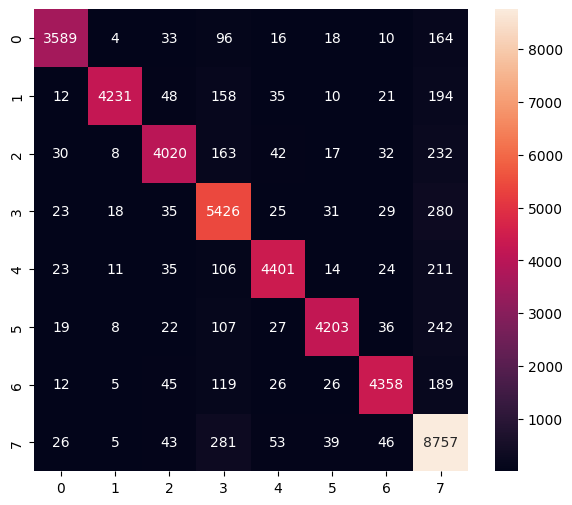

Classification Report
              precision    recall  f1-score   support

           0       0.96      0.91      0.94      3930
           1       0.99      0.90      0.94      4709
           2       0.94      0.88      0.91      4544
           3       0.84      0.92      0.88      5867
           4       0.95      0.91      0.93      4825
           5       0.96      0.90      0.93      4664
           6       0.96      0.91      0.93      4780
           7       0.85      0.95      0.90      9250

    accuracy                           0.92     42569
   macro avg       0.93      0.91      0.92     42569
weighted avg       0.92      0.92      0.92     42569



In [17]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

def print_confusion_matrix(y_true, y_pred, report=True):
    labels = sorted(list(set(y_true)))
    cmx_data = confusion_matrix(y_true, y_pred, labels=labels)
    
    df_cmx = pd.DataFrame(cmx_data, index=labels, columns=labels)
 
    fig, ax = plt.subplots(figsize=(7, 6))
    sns.heatmap(df_cmx, annot=True, fmt='g' ,square=False)
    ax.set_ylim(len(set(y_true)), 0)
    plt.show()
    
    if report:
        print('Classification Report')
        print(classification_report(y_test, y_pred))

Y_pred = model.predict(X_test)
y_pred = np.argmax(Y_pred, axis=1)

print_confusion_matrix(y_test, y_pred)

# Tensorflow-Lite用のモデルへ変換

In [18]:
# 推論専用のモデルとして保存
model.save(model_save_path, include_optimizer=False)

/home/spring/anaconda3/envs/yolo12/lib/python3.11/site-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [19]:
# モデルを変換(量子化)
tflite_save_path = 'model/keypoint_classifier/keypoint_classifier.tflite'

converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_quantized_model = converter.convert()

open(tflite_save_path, 'wb').write(tflite_quantized_model)
open(tflite_save_path, 'wb').write(tflite_quantized_model)

2026-04-08 12:11:32.287451: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-04-08 12:11:32.287468: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-04-08 12:11:32.287627: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmpknqyfdyb
2026-04-08 12:11:32.289215: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-04-08 12:11:32.289222: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /tmp/tmpknqyfdyb
2026-04-08 12:11:32.292782: I tensorflow/compiler/mlir/mlir_graph_optimization_pass.cc:388] MLIR V1 optimization pass is not enabled
2026-04-08 12:11:32.293956: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-04-08 12:11:32.347469: I tensorflow/cc/saved_model/loader.cc:217] Running initialization op on SavedModel bundle at path: /tmp/tmpknqyfdyb
2026-04

183176

# 推論テスト

In [20]:
interpreter = tf.lite.Interpreter(model_path=tflite_save_path)
interpreter.allocate_tensors()

INFO: Created TensorFlow Lite XNNPACK delegate for CPU.


In [21]:
# 入出力テンソルを取得
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

In [22]:
interpreter.set_tensor(input_details[0]['index'], np.array([X_test[0]]))

In [23]:
%%time
# 推論実施
interpreter.invoke()
tflite_results = interpreter.get_tensor(output_details[0]['index'])

CPU times: user 806 μs, sys: 23 μs, total: 829 μs
Wall time: 433 μs


In [24]:
print(np.squeeze(tflite_results))
print(np.argmax(np.squeeze(tflite_results)))

[3.1521315e-15 1.3886592e-15 1.9610305e-10 4.4820994e-15 1.0000000e+00
 2.3729545e-15 5.4194140e-14 2.8727420e-12]
4
